## 📊 Análisis de Ventas en el rubro Farmacéutico 
### Proyecto Final – Data Science

Autor/a: Rubis Becerra

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import statsmodels.api as sm

In [2]:
df = pd.read_csv("../data/processed/pharma_rsnx_processed.csv")

In [3]:
df.head(3)

,Distributor,Customer Name,City,Country,Latitude,Longitude,Channel,Sub-channel,Product Name,Product Class,Quantity,Price,Sales,Month,Year,Name of Sales Rep,Manager,Sales Team,Sales_Level
0,Prohaska-Kuhic,"Wunsch, Mills and Walter",Kielce,Poland,50.8725,20.6319,Pharmacy,Institution,Tacrodomide,Antipiretics,10.0,420,4200.0,January,2018,Stella Given,Alisha Cordwell,Charlie,Low
1,Cassin,Block-Romaguera Pharmaceutical Limited,Tarnowskie Góry,Poland,50.4500,18.8667,Hospital,Private,Finanel,Antimalarial,20.0,206,4120.0,January,2018,Sheila Stones,Britanny Bold,Delta,Low
2,Smith Inc,Doyle-Tillman Pharmaceutical Ltd,Dęblin,Poland,51.5667,21.8614,Hospital,Private,Tacrodomide,Antipiretics,2.0,420,840.0,January,2018,Stella Given,Alisha Cordwell,Charlie,Low


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 19 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Distributor        5000 non-null   object 
 1   Customer Name      5000 non-null   object 
 2   City               5000 non-null   object 
 3   Country            5000 non-null   object 
 4   Latitude           5000 non-null   float64
 5   Longitude          5000 non-null   float64
 6   Channel            5000 non-null   object 
 7   Sub-channel        5000 non-null   object 
 8   Product Name       5000 non-null   object 
 9   Product Class      5000 non-null   object 
 10  Quantity           5000 non-null   float64
 11  Price              5000 non-null   int64  
 12  Sales              5000 non-null   float64
 13  Month              5000 non-null   object 
 14  Year               5000 non-null   int64  
 15  Name of Sales Rep  5000 non-null   object 
 16  Manager            5000 

### Feature Selection

In [5]:
#Se verifican algunas variables que pueden crear overfitting.
df["Product Name"].value_counts()

Product Name
Oxymotroban Fexoformin    33
Alisteride Pemidizem      33
Acelimus                  31
Nevanide Actozide         31
Adriacaine                30
                          ..
Zynosine                  13
Amphesirox                13
Arivac                    12
Relenstrel Exurabine      12
Methiclotide              10
Name: count, Length: 240, dtype: int64

In [6]:
#Se verifican algunas variables que pueden crear overfitting.
df.City.value_counts()

City
Neustadt        18
Bad Oldesloe    17
Offenburg       17
Gummersbach     16
Garbsen         16
                ..
Olsztyn          1
Krapkowice       1
Mysłowice        1
Łęczyca          1
Weinheim         1
Name: count, Length: 744, dtype: int64

In [7]:
#Se eliminan las variables que inicialmente por criterio no sumarían al modelo (identificadoras, jerárquicas y generar overfitting).
columnas_drop = [
    "Distributor", "Customer Name", "City", "Latitude", "Longitude", 
    "Product Name", "Name of Sales Rep", "Manager", "Sales_Level"
]
df_model = df.drop(columns=columnas_drop)

In [8]:
#Se filtran las ventas positivas.
df_model = df_model[df_model["Sales"] > 0]

In [9]:
#Se separan las variables numéricas y las categóricas.
numericas = df_model.select_dtypes(include=["int64", "float64"]).columns
categoricas = df_model.select_dtypes(include=["object"]).columns

#Se verifica la correlación de las variables numéricas que se había analizado en el EDA:
corr = df_model[numericas].corr()
corr["Sales"].sort_values(ascending=False)

Sales       1.000000
Quantity    0.752401
Price       0.117560
Year        0.026072
Name: Sales, dtype: float64

In [10]:
#Se aplica One-Hot Encoding para transformar variables categóricas en variables numéricas binarias.
#Se utiliza drop_first=True para evitar multicolinealidad perfecta y establecer una categoría base de comparación.
#Se establece que el valor final sea tipo entero (dtype=int).

df_model = pd.get_dummies(df_model, drop_first=True, dtype=int)

In [11]:
df_model.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4955 entries, 0 to 4999
Data columns (total 28 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Quantity                        4955 non-null   float64
 1   Price                           4955 non-null   int64  
 2   Sales                           4955 non-null   float64
 3   Year                            4955 non-null   int64  
 4   Country_Poland                  4955 non-null   int64  
 5   Channel_Pharmacy                4955 non-null   int64  
 6   Sub-channel_Institution         4955 non-null   int64  
 7   Sub-channel_Private             4955 non-null   int64  
 8   Sub-channel_Retail              4955 non-null   int64  
 9   Product Class_Antibiotics       4955 non-null   int64  
 10  Product Class_Antimalarial      4955 non-null   int64  
 11  Product Class_Antipiretics      4955 non-null   int64  
 12  Product Class_Antiseptics       4955 no

### Algoritmo de Regresión Lineal Múltiple para entrenar el Modelo

In [12]:
#Por la asimetría y el modelo se aplica log.
df_model["Sales_log"] = np.log(df_model["Sales"])

#### Ejecución 1 del Modelo de Regresión Lineal Múltiple (con Quantity):

In [13]:
#Se separan las variables predictoras del target.
X = df_model.drop(["Sales", "Sales_log"], axis=1)
y = df_model["Sales_log"]

In [14]:
#Se agrega la columna de la constante 1s (intercepto).
X = sm.add_constant(X)

In [15]:
model = sm.OLS(y, X)

In [16]:
results = model.fit()

In [17]:
print(results.summary())

                            OLS Regression Results                            
Dep. Variable:              Sales_log   R-squared:                       0.371
Model:                            OLS   Adj. R-squared:                  0.368
Method:                 Least Squares   F-statistic:                     111.8
Date:                Wed, 18 Feb 2026   Prob (F-statistic):               0.00
Time:                        00:15:30   Log-Likelihood:                -8858.8
No. Observations:                4955   AIC:                         1.777e+04
Df Residuals:                    4928   BIC:                         1.795e+04
Df Model:                          26                                         
Covariance Type:            nonrobust                                         
                                     coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------------
const       

##### Conclusión de la Ejecución 1 del Modelo de Regresión Lineal Múltiple:
El modelo explica un 37% de la variación en el logaritmo de ventas. Las variables Quantity, Price y Country resultaron estadísticamente significativas. Se detecta posible multicolinealidad según el número de condición elevado, es probable que se deba al uso de las variables Quantity (cantidad) ya que Sales es el producto de Quantity * Price.

#### Ejecución 2 del Modelo de Regresión Lineal Múltiple (sin Quantity):

In [18]:
#Para la ejecución 2 del Modelo, se desetimará la variable Quantity
X2 = df_model.drop(["Sales", "Sales_log", "Quantity"], axis=1)
y = df_model["Sales_log"]

In [19]:
X2 = sm.add_constant(X2)

In [20]:
model2 = sm.OLS(y, X2)

In [21]:
results2 = model2.fit()

In [22]:
print(results2.summary())

                            OLS Regression Results                            
Dep. Variable:              Sales_log   R-squared:                       0.229
Model:                            OLS   Adj. R-squared:                  0.225
Method:                 Least Squares   F-statistic:                     58.57
Date:                Wed, 18 Feb 2026   Prob (F-statistic):          1.32e-255
Time:                        00:15:30   Log-Likelihood:                -9362.9
No. Observations:                4955   AIC:                         1.878e+04
Df Residuals:                    4929   BIC:                         1.895e+04
Df Model:                          25                                         
Covariance Type:            nonrobust                                         
                                     coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------------
const       

#### Diagnóstico de Ejecución 2 del Modelo de Regresión Lineal Múltiple (sin Quantity):

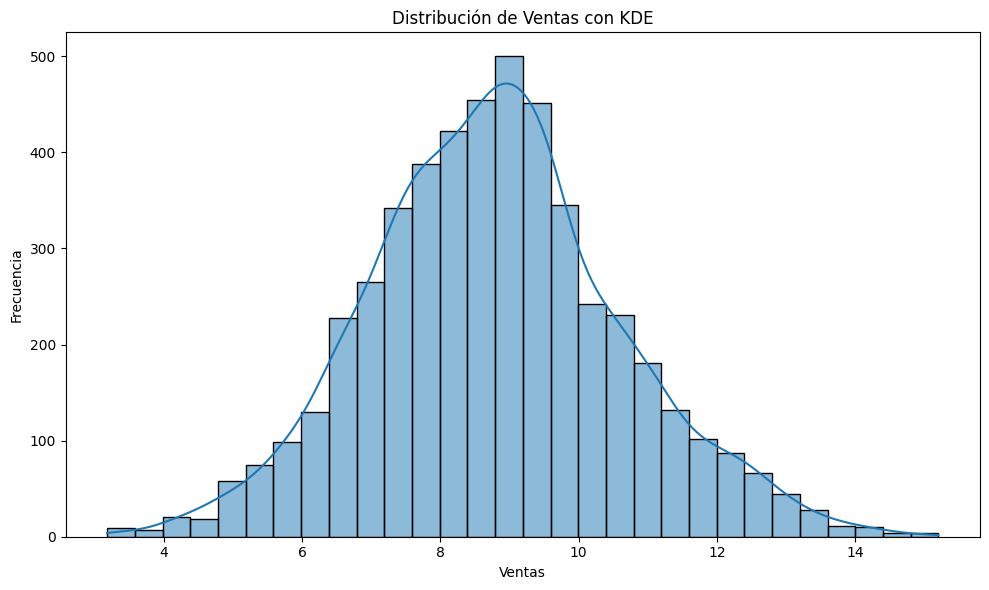

In [23]:
#Se grafica la distribución de la variable "Sales" transformada.
plt.figure(figsize=(10,6))
sns.histplot(data=df_model, x="Sales_log", bins=30, kde=True)
plt.title("Distribución de Ventas con KDE")
plt.xlabel("Ventas")
plt.ylabel("Frecuencia")
ax = plt.gca()
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
plt.tight_layout()
plt.show()

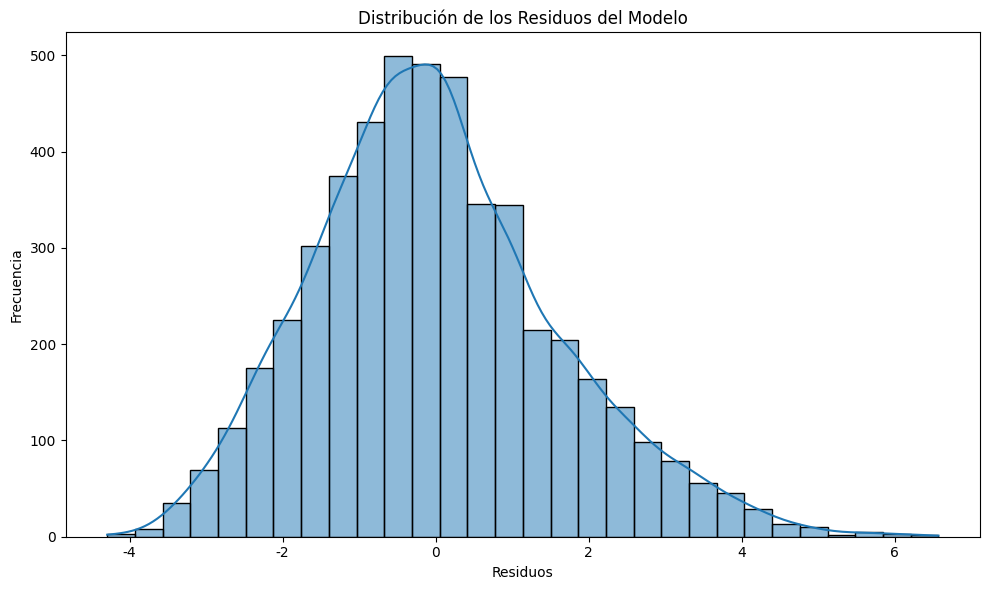

In [24]:
#Se calculan y grafican los Residuos del modelo.
residuos = results2.resid

plt.figure(figsize=(10,6))
sns.histplot(residuos, bins=30, kde=True)
plt.title("Distribución de los Residuos del Modelo")
plt.xlabel("Residuos")
plt.ylabel("Frecuencia")
ax = plt.gca()
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
plt.tight_layout()
plt.show()

<Figure size 1000x600 with 0 Axes>

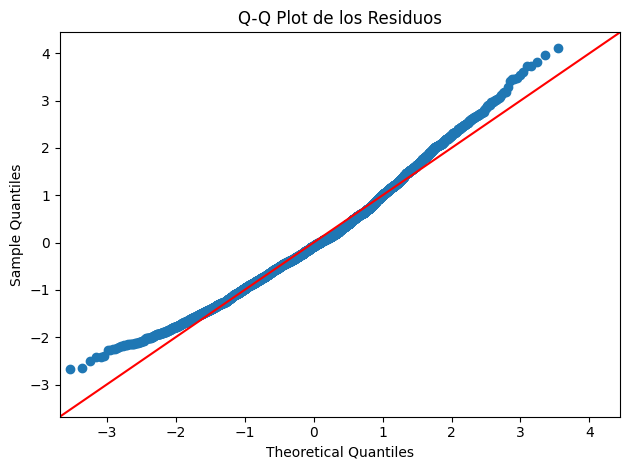

In [25]:
#Gráfico Q-Q.
residuos = results2.resid

plt.figure(figsize=(10,6))
sm.qqplot(residuos, line='45', fit=True)
plt.title("Q-Q Plot de los Residuos")
plt.tight_layout()
plt.show()

#### Comentarios del gráfico Q-Q:
Muestra una adecuada alineación en la parte central de la distribución, aunque se observan desviaciones en los extremos, particularmente en la cola derecha. Esto indica la presencia de residuos con valores elevados positivos, sugiriendo una ligera asimetría y colas más pesadas que la distribución normal teórica. No obstante, dada la magnitud de la muestra, estas desviaciones no comprometen de forma sustancial la validez general del modelo.

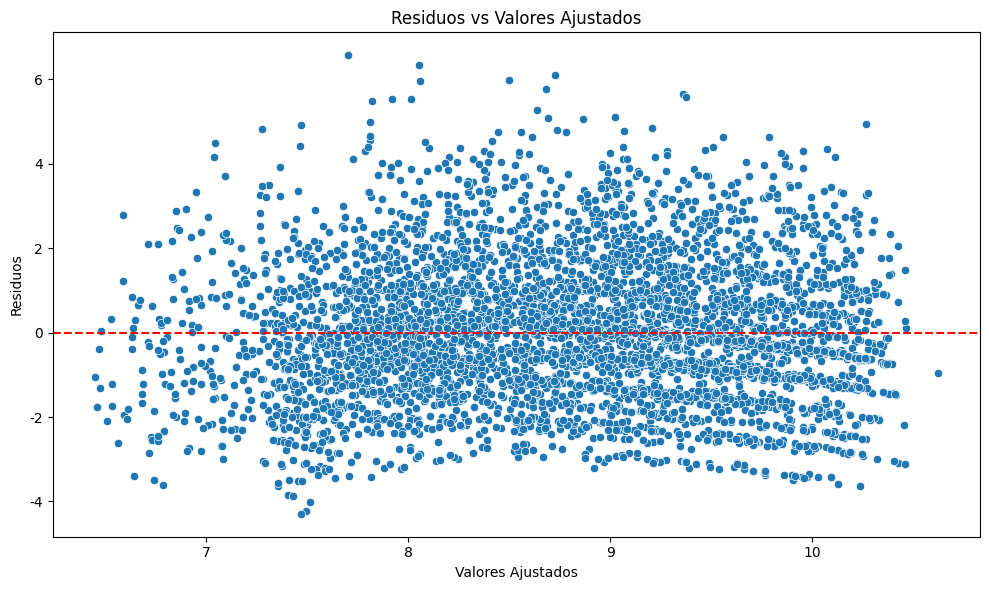

In [26]:
# Gráfico de Residuos vs. Valores Ajustados.
fitted = results2.fittedvalues
residuos = results2.resid

plt.figure(figsize=(10,6))
sns.scatterplot(x=fitted, y=residuos)
plt.axhline(0, color='red', linestyle='--')
plt.title("Residuos vs Valores Ajustados")
plt.xlabel("Valores Ajustados")
plt.ylabel("Residuos")
ax = plt.gca()
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
plt.tight_layout()
plt.show()

#### Comentarios del gráfico Residuos vs Valores Ajustados:
Se visualiza una dispersión aleatoria de los errores alrededor de la línea horizontal en cero, sin evidencias claras de patrones sistemáticos. No se observa una forma de embudo pronunciada ni estructuras curvas que sugieran problemas de heterocedasticidad o no linealidad relevantes. La variabilidad de los residuos se mantiene relativamente constante a lo largo del rango de valores ajustados, lo que respalda el supuesto de homocedasticidad del modelo.

#### Conclusión de Ejecución 2 del Modelo de Regresión Lineal Múltiple (sin Quantity):

Se estimó un modelo de regresión lineal múltiple utilizando como variable dependiente el logaritmo de las ventas (Sales_log), con el objetivo de analizar los factores que influyen en el comportamiento de las ventas sin incluir la variable Quantity, para evitar una relación matemática directa con la variable objetivo.

El modelo presenta un R² de 0.229 (R² ajustado = 0.225), lo que indica que aproximadamente el 22.9% de la variabilidad del logaritmo de las ventas es explicada por las variables independientes incluidas. Aunque el poder explicativo es moderado, el modelo es globalmente significativo (Prob(F-statistic) < 0.001), lo que confirma que, en conjunto, las variables aportan información relevante.

Entre las variables estadísticamente significativas (p < 0.05) destacan:

- *Price*: muestra un efecto positivo y altamente significativo sobre las ventas. Dado que la variable dependiente está en logaritmos, el coeficiente sugiere que incrementos en el precio se asocian con aumentos porcentuales en las ventas.

- *Year*: indica una tendencia temporal positiva, sugiriendo crecimiento de ventas a lo largo del tiempo.

- *Country_Poland*: presenta un efecto negativo significativo, lo que indica que las ventas en este país son considerablemente menores en comparación con el país de referencia *(Germany)*.

- *Product Class_Antiseptics*: muestra un impacto negativo significativo respecto a la categoría base *(Analgesics)*.

- *Month_March*: evidencia un efecto estacional positivo, sugiriendo un incremento significativo de ventas en ese mes en comparación con el mes de referencia *(April)*.

La mayoría de las variables relacionadas con canal, subcanal, equipo de ventas y otros meses no resultaron estadísticamente significativas, lo que sugiere que su impacto sobre las ventas no es determinante dentro de este modelo.

Adicionalmente, el elevado número de condición (1.00e+16) indica posibles problemas de multicolinealidad entre algunas variables explicativas, lo cual puede afectar la estabilidad de los coeficientes estimados. Sin embargo, el modelo mantiene coherencia económica en los principales efectos identificados.

En conclusión, el modelo logra identificar factores estructurales relevantes que influyen en las ventas (precio, país, tendencia temporal y estacionalidad específica), aunque su capacidad explicativa es moderada. Para fines predictivos, sería recomendable complementar este análisis con validación fuera de muestra y explorar técnicas de regularización para mitigar posibles problemas de multicolinealidad.